<a href="https://colab.research.google.com/github/tumatidurga/collab/blob/main/smart_healthcare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

In [2]:
from google.colab import files

uploaded = files.upload()

Saving healthcare-dataset-stroke-data.csv to healthcare-dataset-stroke-data.csv


In [3]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv')

In [4]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [5]:
print("Shape of dataset:", df.shape)

Shape of dataset: (5110, 12)


In [6]:
print("\nData types:\n", df.dtypes)


Data types:
 id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object


In [7]:
print("\nDataset info:")
df.info()


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [8]:
print("\nUnique values per column:\n", df.nunique())


Unique values per column:
 id                   5110
gender                  3
age                   104
hypertension            2
heart_disease           2
ever_married            2
work_type               5
Residence_type          2
avg_glucose_level    3979
bmi                   418
smoking_status          4
stroke                  2
dtype: int64


In [9]:
for col in ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'stroke']:
    print(f"\nValue counts for {col}:\n", df[col].value_counts())


Value counts for gender:
 gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

Value counts for ever_married:
 ever_married
Yes    3353
No     1757
Name: count, dtype: int64

Value counts for work_type:
 work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

Value counts for Residence_type:
 Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

Value counts for smoking_status:
 smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789
Name: count, dtype: int64

Value counts for stroke:
 stroke
0    4861
1     249
Name: count, dtype: int64


In [10]:
nulls = df.isnull().sum()
print("Null values in each column:\n", nulls)


Null values in each column:
 id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64


In [12]:
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

In [13]:
nulls_remaining = df['bmi'].isnull().sum()
print(f"Number of nulls remaining in 'bmi': {nulls_remaining}")

Number of nulls remaining in 'bmi': 0


In [15]:
print("\nNulls after handling:\n", df.isnull().sum())


Nulls after handling:
 id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


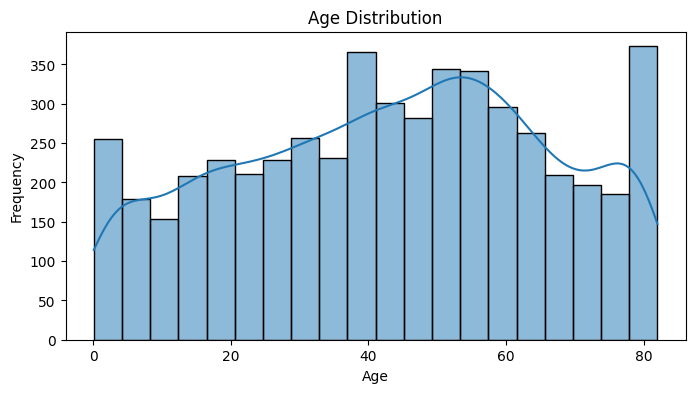

In [16]:
plt.figure(figsize=(8, 4))
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

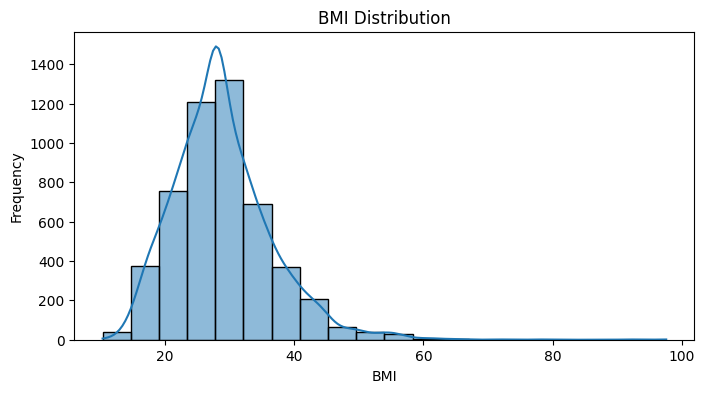

In [17]:
plt.figure(figsize=(8, 4))
sns.histplot(df['bmi'], bins=20, kde=True)
plt.title('BMI Distribution')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

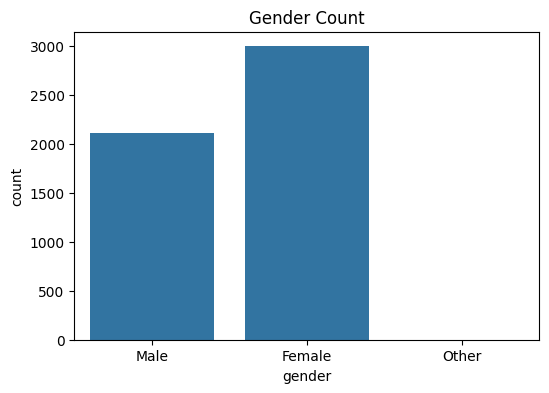

In [18]:
plt.figure(figsize=(6, 4))
sns.countplot(x='gender', data=df)
plt.title('Gender Count')
plt.show()

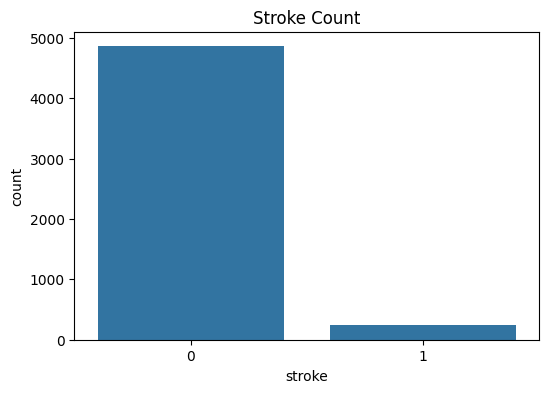

In [19]:
plt.figure(figsize=(6, 4))
sns.countplot(x='stroke', data=df)
plt.title('Stroke Count')
plt.show()


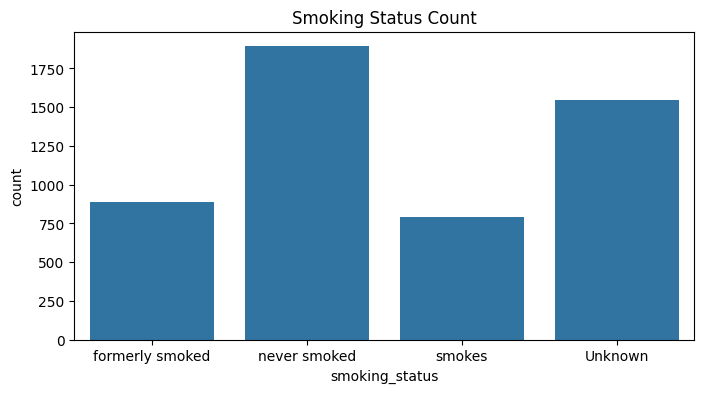

In [20]:
plt.figure(figsize=(8, 4))
sns.countplot(x='smoking_status', data=df)
plt.title('Smoking Status Count')
plt.show()

In [22]:
label_encoders = {}
for col in ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Encode target variable 'stroke' (already 0/1, but ensure)
df['stroke'] = df['stroke'].astype(int)

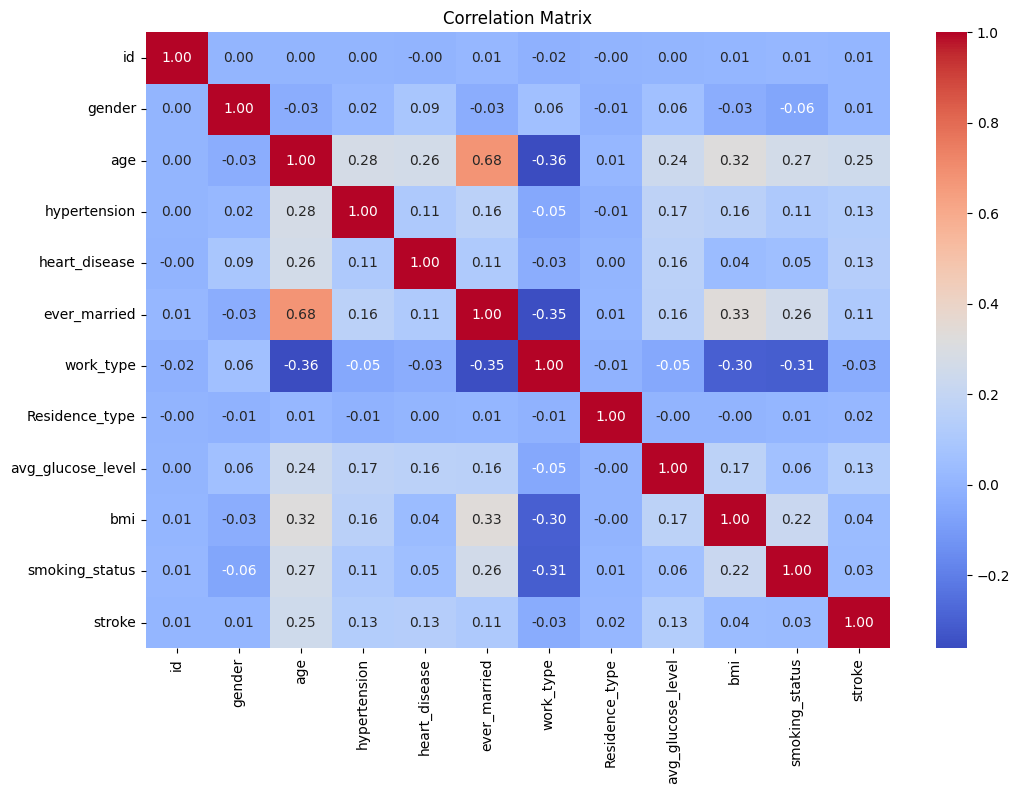

In [23]:
corr_matrix = df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

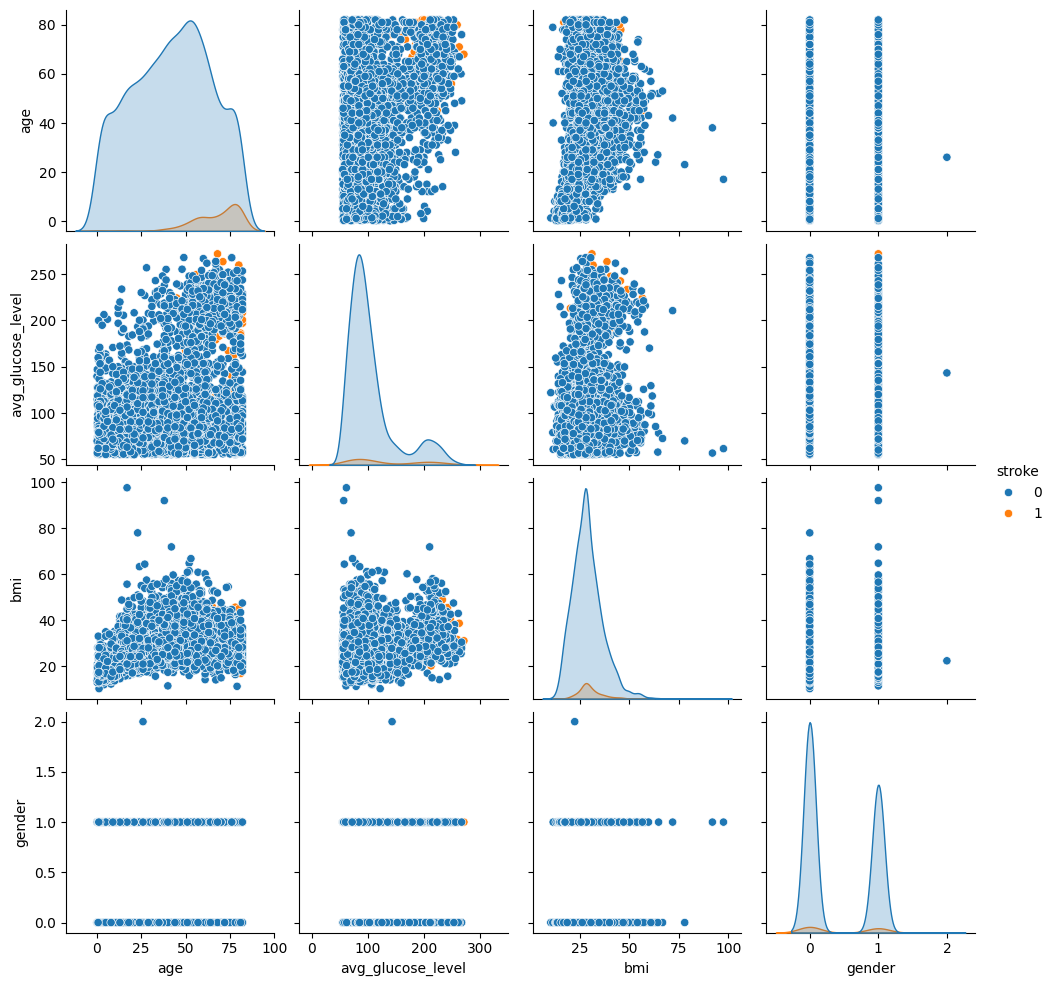

In [24]:
sns.pairplot(df[['age', 'avg_glucose_level', 'bmi', 'gender', 'stroke']], hue='stroke')
plt.show()

In [25]:
# Define features and target
X = df.drop('stroke', axis=1)
y = df['stroke']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    # Fit model
    model.fit(X_train, y_train)
    # Predict
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else 'N/A'
    cm = confusion_matrix(y_test, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC Score: {roc_auc}")
    print("Confusion Matrix:\n", cm)

In [29]:
lr = LogisticRegression()
evaluate_model(lr, X_train, y_train, X_test, y_test)

Accuracy: 0.9501
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
ROC-AUC Score: 0.8361728395061728
Confusion Matrix:
 [[971   1]
 [ 50   0]]


In [30]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
evaluate_model(rf, X_train, y_train, X_test, y_test)

Accuracy: 0.9481
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
ROC-AUC Score: 0.7999588477366255
Confusion Matrix:
 [[969   3]
 [ 50   0]]


In [31]:
svm = SVC(probability=True, kernel='rbf')
evaluate_model(svm, X_train, y_train, X_test, y_test)

Accuracy: 0.9511
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
ROC-AUC Score: 0.6399176954732511
Confusion Matrix:
 [[972   0]
 [ 50   0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [32]:
knn = KNeighborsClassifier(n_neighbors=5)
evaluate_model(knn, X_train, y_train, X_test, y_test)

Accuracy: 0.9501
Precision: 0.3333
Recall: 0.0200
F1-Score: 0.0377
ROC-AUC Score: 0.602849794238683
Confusion Matrix:
 [[970   2]
 [ 49   1]]


In [33]:
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
evaluate_model(mlp, X_train, y_train, X_test, y_test)

Accuracy: 0.9491
Precision: 0.3750
Recall: 0.0600
F1-Score: 0.1034
ROC-AUC Score: 0.7890946502057613
Confusion Matrix:
 [[967   5]
 [ 47   3]]


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
